# Install

In [1]:
from pathlib import Path

_nb = globals().get("__vsc_ipynb_file__")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
REQ = next(
    p / "ai" / "experiments" / "requirements.txt"
    for p in (_start, *_start.parents)
    if (p / "ai" / "experiments" / "requirements.txt").exists()
)
!pip install -r "{REQ}"

  Using cached pandas-2.2.2.tar.gz (4.4 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      + meson setup C:\Users\104go\AppData\Local\Temp\pip-install-broispza\pandas_62ec517c1f4e4980a4adcdf1f8cebbc0 C:\Users\104go\AppData\Local\Temp\pip-install-broispza\pandas_62ec517c1f4e4980a4adcdf1f8cebbc0\.mesonpy-9orsnb1z\build -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --vsenv --native-file=C:\Users\104go\AppData\Local\Temp\pip-install-broispza\pandas_62ec517c1f4e4980a4adcdf1f8cebbc0\.mesonpy-9orsnb1z\build\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.1
      Source dir: C:\Users\104go\AppData\Local\Temp\pip-install-broispza\pandas_62ec517c1f4e4980a4adcdf1f8cebbc0
      Build dir: C:\Users\104go\AppData\Local\Temp\pip-install-broispza\pandas_62ec517c1f4e4980a4adcdf1f8cebbc0\.mesonpy-9orsnb1z\build
      Build type: native build
      Project name: pandas
      Project version: 2.2.2
    

# [영화 평가 데이터](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset/data)
- 이 파일에는 Full MovieLens 데이터셋에 등록된 45,000편의 영화에 대한 메타데이터가 포함되어 있습니다.
- 이 데이터셋은 2017년 7월 이전에 개봉한 영화로 구성되어 있습니다. 데이터 포인트에는 출연진, 제작진, 줄거리 키워드, 예산, 수익, 포스터, 개봉일, 언어, 제작사, 국가, TMDB 투표 수 및 투표 평균 등이 포함됩니다.
- 이 데이터세트에는 45,000편의 영화에 대해 27만 명의 사용자가 작성한 2,600만 건의 평점이 포함된 파일도 포함되어 있습니다.
- 평점은 1점부터 5점까지의 점수로 매겨지며, GroupLens 공식 웹사이트에서 수집되었습니다.

# 데이터

## 데이터 로드

In [ ]:
# 데이터 분석에 사용할 라이브러리
import numpy as np
import pandas as pd
from pathlib import Path

# ponytail: notebook moved to ai/experiments — anchor from notebook dir, not kernel cwd
_nb = globals().get("__vsc_ipynb_file__")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
_marker = Path("storage") / "processed" / "recipe" / "recipe_fix.csv"

ROOT = next(p for p in (_start, *_start.parents) if (p / _marker).exists())
RECIPE_FIX_CSV = ROOT / _marker
RECIPE_INGRED_ALIAS_CSV = ROOT / "storage" / "processed" / "recipe" / "recipe_ingredient_alias.csv"




### recipes Metadata

In [4]:
recipe = pd.read_csv(RECIPE_FIX_CSV)
recipe.head(1)
recipe.shape

(3171, 31)

In [5]:
ingred = pd.read_csv(RECIPE_INGRED_ALIAS_CSV)
ingred.head(20)
ingred.shape

(3171, 9)

In [8]:
recipe.head(1)

,RCP_SNO,CKG_NM,INQ_CNT,SRAP_CNT,CKG_MTH_ACTO_NM,CKG_STA_ACTO_NM,CKG_MTRL_ACTO_NM,CKG_KND_ACTO_NM,CKG_MTRL_CN,CKG_INBUN_NM,...,INQ_CNT_RATE_2024,INQ_CNT_LOG_2024,INQ_CNT_LOG_CENTERED_2024,INQ_CNT_2026,INQ_CNT_2026_CRAWLED_AT_UTC,INQ_CNT_DELTA_2024_2026,INQ_CNT_GROWTH_RATE_2024_2026,INQ_CNT_RATE_2026,INQ_CNT_LOG_2026,INQ_CNT_LOG_CENTERED_2026
0,7016814,된장수육,1396,1,삶기,술안주,돼지고기,메인반찬,"[['돼지고기 수육용삼겹살', '500', 'g'], [' 된장', '1.5', '...",2인분,...,0.022969,7.242082,-0.526618,2042.0,2026-07-07T06:07:03.230726+00:00,646.0,0.462751,0.012285,7.622175,-0.883357


> 사용할 컬럼만 남기고 나머지 드랍

In [12]:
columns = [
    'RCP_SNO', 'CKG_NM', 'CKG_KND_ACTO_NM', 'CKG_MTH_ACTO_NM', 'CKG_MTRL_ACTO_NM',
    'INQ_CNT_LOG_CENTERED', 'SRAP_CNT_LOG_CENTERED',
]

recipe = recipe[columns].copy()
recipe.head(1)

,RCP_SNO,CKG_NM,CKG_KND_ACTO_NM,CKG_MTH_ACTO_NM,CKG_MTRL_ACTO_NM,INQ_CNT_LOG_CENTERED,SRAP_CNT_LOG_CENTERED
0,7016814,된장수육,메인반찬,삶기,돼지고기,-0.526618,-1.618524


> 

### Merge(합치기)

In [14]:
# Merge ingred's relevant columns onto movies by RCP_SNO
if 'RCP_SNO' in recipe.columns and 'RCP_SNO' in ingred.columns:
    recipe = recipe.merge(
        ingred[['RCP_SNO', 'aliases_matched', 'ingredients_normalized']],
        on='RCP_SNO',
        how='left'
    )

recipe.head(1)

,RCP_SNO,CKG_NM,CKG_KND_ACTO_NM,CKG_MTH_ACTO_NM,CKG_MTRL_ACTO_NM,INQ_CNT_LOG_CENTERED,SRAP_CNT_LOG_CENTERED,aliases_matched_x,ingredients_normalized_x,aliases_matched_y,ingredients_normalized_y
0,7016814,된장수육,메인반찬,삶기,돼지고기,-0.526618,-1.618524,"[{""alias_id"": ""alias_0843"", ""name"": ""삼겹살""}, {""...","[[""삼겹살"", ""500"", ""g""], [""된장"", ""1.5"", ""큰술""], [""술...","[{""alias_id"": ""alias_0843"", ""name"": ""삼겹살""}, {""...","[[""삼겹살"", ""500"", ""g""], [""된장"", ""1.5"", ""큰술""], [""술..."


## 데이터 분석

> rating(별점) 분포도 확인

> 사용자 분석

> 영화 분석

## 데이터 전처리

### 데이터 정규화
- 각 영화의 평균 평점을 빼는 방식으로 데이터를 정규화할 것입니다.

### 정규성 변환

### new rating with MinMax Scaling

> new_rating이 rating보다 안정적인 정규분포를 따르는 것을 볼 수 있다.

## 데이터 결측치 제거

# Model Based Collaborative Filtering

## [LightFM](https://making.lyst.com/lightfm/docs/home.html)
Python 기반의 추천 시스템 라이브러리로, **협업 필터링(Collaborative Filtering)**과 **내용 기반 필터링(Content-Based Filtering)**을 결합할 수 있는 하이브리드 추천 시스템을 쉽게 구현할 수 있게 해줍니다.

### 특징

| 특징                               | 설명                                          |
| -------------------------------- | ------------------------------------------- |
| 🔄 **하이브리드 필터링**                 | 협업 필터링(CF) + 콘텐츠 기반(Content-Based) 방식 모두 지원 |
| ⚙️ **임베딩 기반 모델**                 | 사용자/아이템을 벡터로 임베딩하여 내적(dot product)으로 선호도 예측 |
| ⚡ **고속 구현**                      | 내부적으로 Cython으로 구현되어 빠른 학습 가능                |
| 💡 **암묵적 & 명시적 피드백 모두 지원**       | 클릭/구매 같은 암묵적 데이터, 평점 같은 명시적 데이터 모두 처리 가능    |
| 🧩 **사용자/아이템 특성(feature) 입력 가능** | cold-start 문제 완화 가능                         |


### 손실함수

| 손실 함수        | 특징                                 | 사용 추천        |
| ------------ | ---------------------------------- | ------------ |
| `'logistic'` | 확률 기반, 명시적/암묵적 모두 가능               | 기본 선택        |
| `'bpr'`      | Bayesian Personalized Ranking      | 순위 기반 추천     |
| `'warp'`     | Weighted Approximate-Rank Pairwise | top-k 추천 최적화 |
| `'warp-kos'` | WARP의 개선형                          | 희귀 아이템에 강함   |


## User-Item Matrix 변환

> 아래와 같이 userId와 movieId는 인덱스값이 아님 따라서 재정의 필요

In [30]:
ratings[['userId', 'movieId', 'new_rating']].head()

,userId,movieId,new_rating
0,1,1371,2.832340
1,1,1405,1.998271
2,1,2105,3.438105
3,1,2193,2.466338
4,1,2294,2.426195


> 고유 유저와 아이템 목록

In [31]:
user_ids = ratings['userId'].unique()
item_ids = ratings['movieId'].unique()

In [32]:
len(user_ids), len(item_ids)

(671, 1548)

> LightFM Dataset 초기화 및 fitting

In [33]:
from lightfm.data import Dataset

dataset = Dataset()
dataset.fit(users=user_ids, items=item_ids)

> interactions 생성

In [34]:
(interactions, weights) = dataset.build_interactions(
    [(row['userId'], row['movieId'], row['new_rating']) for _, row in ratings.iterrows()]
)

> 생성된 User-Item Matrix 확인

In [35]:
interactions.shape

(671, 1548)

In [36]:
interactions.toarray()

array([[1, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)

In [37]:
import pandas as pd

df_interactions = pd.DataFrame({
    'userId': interactions.row, # 행 인덱스
    'movieId': interactions.col, # 열 인덱스
    'new_rating': interactions.data # 실제 값
})

print(df_interactions.head())

   userId  movieId  new_rating
0       0        0           1
1       0        1           1
2       0        2           1
3       0        3           1
4       0        4           1


## Train/Test split

| 구분      | 역할    | 비유                |
| ------- | ----- | ----------------- |
| 훈련 데이터  | 공부    | 시험을 대비한 학습 과정     |
| 테스트 데이터 | 실제 시험 | 외부에 모델을 공개하기 전 평가 |


In [38]:
from lightfm.cross_validation import random_train_test_split

In [39]:
train, test = random_train_test_split(interactions, test_percentage=0.2, random_state=42)

# 출력
print(f"전체 interactions 수: {interactions.nnz}")
print(f"Train interactions 수: {train.nnz}")
print(f"Test interactions 수: {test.nnz}")

전체 interactions 수: 32136
Train interactions 수: 25708
Test interactions 수: 6428


## Model - Latent Matrix Factorization

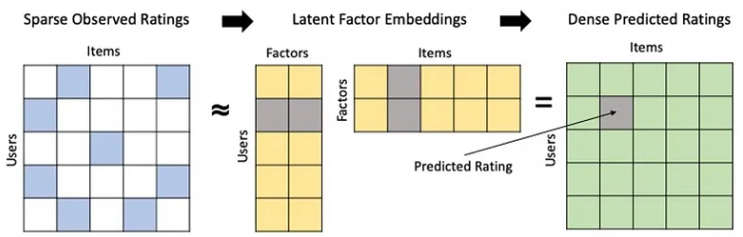

In [40]:
from lightfm import LightFM

# 모델 생성
# warp(Weighted Approximate-Rank Pairwise): 암묵적 피드백에서 자주 쓰임
model = LightFM(loss='warp')

## Training

### 학습 그래프(Precision@K)
- 모델이 제대로 학습되고 있는지 확인할 수 있습니다.

In [41]:
import matplotlib.pyplot as plt
from lightfm.evaluation import precision_at_k

In [42]:
precisions = []

epochs = 30
for epoch in range(epochs):
    model.fit_partial(train, epochs=1, num_threads=2)
    precision = precision_at_k(model, train, k=5).mean()
    precisions.append(precision)
    print(f"Epoch {epoch+1}/{epochs}, Precision@5: {precision:.4f}")

Epoch 1/30, Precision@5: 0.3666
Epoch 2/30, Precision@5: 0.3729
Epoch 3/30, Precision@5: 0.3768
Epoch 4/30, Precision@5: 0.3940
Epoch 5/30, Precision@5: 0.4024
Epoch 6/30, Precision@5: 0.4155
Epoch 7/30, Precision@5: 0.4316
Epoch 8/30, Precision@5: 0.4405
Epoch 9/30, Precision@5: 0.4495
Epoch 10/30, Precision@5: 0.4587
Epoch 11/30, Precision@5: 0.4644
Epoch 12/30, Precision@5: 0.4733
Epoch 13/30, Precision@5: 0.4751
Epoch 14/30, Precision@5: 0.4784
Epoch 15/30, Precision@5: 0.4793
Epoch 16/30, Precision@5: 0.4769
Epoch 17/30, Precision@5: 0.4829
Epoch 18/30, Precision@5: 0.4841
Epoch 19/30, Precision@5: 0.4945
Epoch 20/30, Precision@5: 0.4930
Epoch 21/30, Precision@5: 0.4975
Epoch 22/30, Precision@5: 0.4966
Epoch 23/30, Precision@5: 0.4927
Epoch 24/30, Precision@5: 0.4978
Epoch 25/30, Precision@5: 0.4999
Epoch 26/30, Precision@5: 0.5025
Epoch 27/30, Precision@5: 0.5055
Epoch 28/30, Precision@5: 0.5052
Epoch 29/30, Precision@5: 0.5055
Epoch 30/30, Precision@5: 0.5049


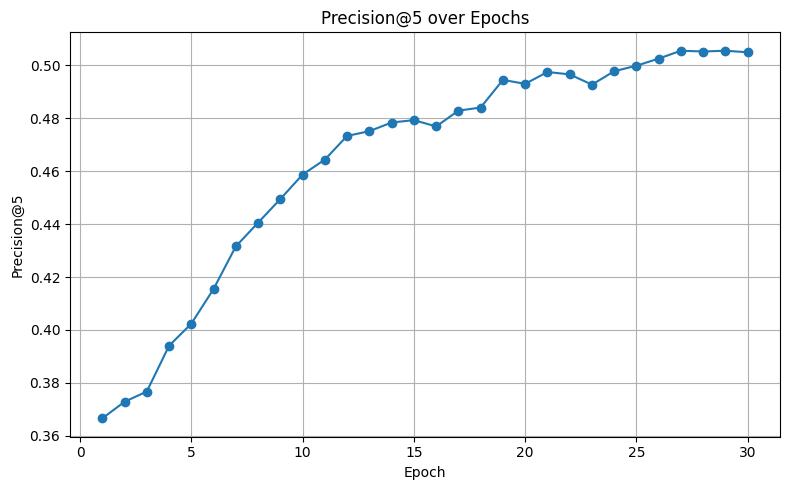

In [43]:
# 그래프 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), precisions, marker='o')
plt.title('Precision@5 over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision@5')
plt.grid(True)
plt.tight_layout()
plt.show()

### 일반적인 모델 학습 코드

In [44]:
# 모델 생성
model = LightFM(loss='warp')

# 모델 학습
model.fit(train, epochs=30, num_threads=2)

## Prediction

In [45]:
# user 0에게 추천할 item 5개
n_users, n_items = interactions.shape
user_id = 0

scores = model.predict(user_id, np.arange(n_items))
top_items = np.argsort(-scores)[:5]

print(f"\nUser {user_id} 추천:")
for item in top_items:
    print(f"  item {item}, 예측 점수: {scores[item]:.2f}")


User 0 추천:
  item 70, 예측 점수: 1.82
  item 92, 예측 점수: 1.65
  item 148, 예측 점수: 1.47
  item 105, 예측 점수: 1.46
  item 151, 예측 점수: 1.41


## Evaluation

### Precision@K
- Precision@K는 추천 시스템에서 자주 사용되는 Top-K 평가 지표 중 하나로, 사용자에게 추천한 K개의 아이템 중 실제로 사용자가 좋아한(또는 상호작용한) 아이템이 몇 개인지를 측정지표이다.
- 높을수록 좋은 성능

In [46]:
from lightfm.evaluation import precision_at_k

precision = precision_at_k(model, test, k=10).mean()
print(f"Precision@10: {precision:.4f}")

Precision@10: 0.0872


### Recall@K
- Recall@K는 추천 시스템에서 사용자가 실제로 좋아하거나 상호작용한 아이템들 중에서, 추천한 K개 중에 몇 개를 맞췄는지를 측정하는 포괄성 평가 지표입니다.
- 값이 클수록 추천이 포괄적으로 잘 됨

In [47]:
from lightfm.evaluation import recall_at_k

recall = recall_at_k(model, test, k=10).mean()
print(f"Recall@10: {recall:.4f}")

Recall@10: 0.1475


## Recommendation

In [48]:
def recommendation_CF(user_id, k=3):
    n_users, n_items = interactions.shape

    # 예측 점수 계산
    scores = model.predict(user_id, np.arange(n_items))

    # 이미 상호작용한 아이템 가져오기
    known_items = interactions.tocsr()[user_id].indices

    # 예측 점수 중 이미 본 아이템은 -inf로 설정하여 제외
    scores[known_items] = -np.inf

    # top-K 추천
    top_items = np.argsort(-scores)

    # 추천 리스트
    rating_prediction ={}
    for item in top_items:
        try:
            unwatched_movie = ratings[ratings['movieId'] == item]['title'].values[0]
            rating_prediction[unwatched_movie] = float(scores[item])
        except:
            pass

    # 가장 높은 예측 평점을 가진 영화들을 추천 결과로 반환
    recommended_movies = pd.DataFrame(rating_prediction.items(), columns=['title', 'predicted_rating'])
    return recommended_movies.sort_values(by=['predicted_rating'], ascending=False)[:k]

In [49]:
recommendation_CF(user_id=0)

,title,predicted_rating
0,Million Dollar Baby,1.823350
1,The Secret Life of Words,1.474587
2,Back to the Future,1.460527


예측 점수가 음수인 경우가 발생할 수 있음   
- 학습 데이터가 부족한 사용자/아이템인 경우(Cold Start) 예측 점수가 작거나 음수일 확률이 높음
- 예측 점수는 양수/음수 모두 가능하며, 값이 중요한 것이 아니라 상대적 우선순위가 중요함

In [50]:
recommendation_CF(user_id=14)

,title,predicted_rating
0,Star Trek: First Contact,-4.725932
1,48 Hrs.,-4.896823
2,Pirates of the Caribbean: Dead Man's Chest,-5.248486
